# Retrieval

In [1]:
import numpy as np # Used for return type and embeddings .
import open_clip # Used to load image embedding model  .
import torch # Used for device handling and tensor operations .
import os # Used for locating database storage .
from sentence_transformers import SentenceTransformer # Used to load text embedding model .
import chromadb # Used for vectorDB operations .
from typing import Dict # Used for datatype handling .

In [2]:
# Used image embedding and query embedding .
class OpenClipTextEmbeddingModel:
     def __init__(self,model_name:str="ViT-B-32",pretrained:str="laion2b_s34b_b79k"):

        self.device="cuda" if torch.cuda.is_available() else "cpu" # Used to check if the machine has GPU if not assign CPU as device for working .
        self.model,self.preprocess,_=open_clip.create_model_and_transforms(
            model_name=model_name,
            pretrained=pretrained
        ) # Getting essential function from model .
        self.tokenizer=open_clip.get_tokenizer(model_name)
        self.model=self.model.to(self.device) # Device selection for model operations .
        self.model.eval() # Loading model

        # Displaying device on which model will run .
        if self.device=="cuda":
            print(f"OpenClip running on {torch.cuda.get_device_name(0)} .")
        else:
            print("OpenClip running on CPU .")
        print(f"Embedding dimensions of {model_name} is {open_clip.get_model_config(model_name).get('embed_dim')}")

     @torch.no_grad()
     def embed_query(self,query:str)->np.ndarray:
         if not query.strip():
             raise ValueError("Please give a valid prompt .")

         tokens=self.tokenizer([query]).to(self.device) # Used to convert into tensor .
         query_embedding=self.model.encode_text(tokens) # Embedding text or tensor value .
         query_embedding=query_embedding/query_embedding.norm(dim=-1,keepdim=True) # Normalizing values
         query_embedding=query_embedding.cpu().numpy()[0] # Converting tensor to numpy array .

         return query_embedding # Returning all the embeddings .

In [3]:
image_model=OpenClipTextEmbeddingModel()

OpenClip running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Embedding dimensions of ViT-B-32 is 512


In [4]:
# Used for text embedding and query embedding .
class BGETextEmbeddingModel:

    def __init__(self,model_name:str= "BAAI/bge-base-en-v1.5"):
        self.device="cuda" if torch.cuda.is_available() else "cpu" # Device check .
        self.model=SentenceTransformer(model_name_or_path=model_name,device=self.device) # Loading model .
        self.query_prefix="Represent this sentence for searching relevant passages: "
        if self.device=="cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)} .")
        else:
            print("BGE running on CPU .")
        print(f"Dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:

        if not query.strip():
            raise ValueError("Given prompt is not valid .")

        query=self.query_prefix + query # Adding a prefix to prompt since BGE is instruction based embedding model .(Only for prompt not mandatory for documents)

        query_embedding=self.model.encode( # Embedding query .
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        return query_embedding # Returning embedded values .

In [5]:
text_model=BGETextEmbeddingModel()

BGE running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Dimension of BAAI/bge-base-en-v1.5 is 768


In [6]:
class VectorStore:
    def __init__(self,collection_name:str,directory:str="../data/database"):
        self.collection_name=collection_name # Collection name .
        self.persistent_directory=directory # Directory to store database .
        self.collection=None # Collection , used to store data .
        self.client=None # Used to connect database .
        self.initialize_store() # Initializing vectordb .

    def initialize_store(self):
            try:
                os.makedirs(name=self.persistent_directory,exist_ok=True) # Checking if directory exists ,if not creating one .
                self.client=chromadb.PersistentClient(path=self.persistent_directory)

                if self.collection_exists(self.collection_name): # Checking if the collection exists , if collection exists then loading it .
                    print(f"Loading collection {self.collection_name} from database .")
                    self.collection=self.client.get_collection(self.collection_name)

                else: # If collection does not exist then creating it .
                    print(f"New collection {self.collection_name} created in database .")
                    self.collection=self.client.create_collection(self.collection_name)

                print(f"Vector store initialized .") # Success message is vector store initialized .
                print(f"Existing documents in collection {self.collection.count()}")

            except Exception as e: # Exception handling .
                raise RuntimeError("Could not initialize vector store .") from e
    # The following function is used to check if the collection exists .
    def collection_exists(self,collection_name:str)->bool:
        collection_in_db=self.client.list_collections()
        return any(col.name==collection_name for col in collection_in_db )

    # The following function is used get queries and get relevant documents
    def query(self,query_embedding:np.ndarray,k:int=5,where:Dict | None=None):

        if not self.collection: # Checking if collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if query_embedding.ndim!=1: # Checking if query is single dimension .
            raise ValueError("Query embedding must be a 1D vector .")

        results=self.collection.query( # Embedding query .
            query_embeddings=[query_embedding.tolist()],
            n_results=k,
            where=where,
            include=["documents","metadatas","distances"]
        )
        return results # Returning results .

In [7]:
Image_vector_store=VectorStore(collection_name="OpenClip_embeddings") # Using existing data from database .

Loading collection OpenClip_embeddings from database .
Vector store initialized .
Existing documents in collection 99


In [8]:
Text_vector_store=VectorStore(collection_name="BGE_embeddings") # Using existing data from database .

Loading collection BGE_embeddings from database .
Vector store initialized .
Existing documents in collection 97


In [9]:
from sentence_transformers import CrossEncoder
from typing import List,Optional

In [10]:
# Used to rerank the chunks with relevance .
class Reranker:
    def __init__(self):# Initializing model .
        self.model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
        print("Reranker initialized")

    def rerank(
        self,query: str,items: List[Dict],top_k: int = 3) -> List[Dict]:

        if not items: # Checking if chunks are empty .
            return []

        pairs = [[query, item["text"]] for item in items]
        scores = self.model.predict(pairs) # Reranking distances .

        ranked = sorted( # Ranking based of distance .
            zip(items, scores),
            key=lambda x: x[1],
            reverse=True # Since lower the distance higher the relevance .
        )

        return [item for item, _ in ranked[:top_k]] # Returning top k chunks .

In [11]:
from PIL import Image
import os
from typing import List,Dict,Optional

In [12]:
# Used to format retrieved docs from retrieval output .
class ContextFormatter:

    def __init__(self,max_text_chunks:int=3,max_images:int=1,text_distance_threshold:float=0.65,image_distance_threshold:float=0.95):
        if not isinstance(max_text_chunks, int) or max_text_chunks <= 0: # Threshold value validation .
            raise ValueError(f"max_text_chunks must be a positive integer, got {max_text_chunks}.")

        if not isinstance(max_images, int) or max_images <= 0:
            raise ValueError(f"max_images must be a positive integer, got {max_images}.")

        if not isinstance(text_distance_threshold, (int, float)) or text_distance_threshold < 0:
            raise ValueError(f"text_distance_threshold must be a non-negative number, got {text_distance_threshold}.")

        if not isinstance(image_distance_threshold, (int, float)) or image_distance_threshold < 0:
            raise ValueError(f"image_distance_threshold must be a non-negative number, got {image_distance_threshold}.")

        self.max_text_chunks=max_text_chunks # Limiting number of chunks .
        self.max_images=max_images # Limiting number of max images .
        self.text_distance_threshold=float(text_distance_threshold) # Threshold for filtering chunks .
        self.image_distance_threshold=float(image_distance_threshold) # Threshold for filtering images .

    # Removing unwanted details from results .
    def _flatten_results(self,results:Dict)->List[Dict]:

        if not results or not isinstance(results,dict): # Checking if data is empty .
            return []

        documents=results.get("documents",[[]])[0]
        metadatas=results.get("metadatas",[[]])[0]
        distances=results.get("distances",[[]])[0]

        documents = results.get("documents", [[]])
        metadatas = results.get("metadatas", [[]])
        distances = results.get("distances", [[]])

        # Check if we have valid nested lists .
        if not documents or not isinstance(documents, list) or len(documents) == 0:
            return []

        docs = documents[0] if len(documents) > 0 else []
        metas = metadatas[0] if len(metadatas) > 0 else []
        dists = distances[0] if len(distances) > 0 else []

        # Ensure all lists have the same length .
        min_length = min(len(docs), len(metas), len(dists))
        if min_length == 0:
            return []

        flattened=[]
        for i in range(min_length):
            flattened.append({ # Appending required data .
                "text":docs[i],
                "metadata":metas[i],
                "distance":float(dists[i])
            })

        return flattened # Returning flattened data .

    # The following function is used to load image from path .
    def _load_image(self,image_path:str) -> Optional[Image.Image]:

        if not image_path or not isinstance(image_path, str): # Checking is image path is valid .
            return None

        if not os.path.exists(image_path):
            print(f"Warning: Image path does not exist: {image_path}")
            return None

        try:
            return Image.open(image_path).convert("RGB") # Returning loaded image .
        except Exception as e:
            print(f"Failed to load image {image_path}: {e}")
            return None

    # The following function is filter text chunks based on distance .
    def _select_text_chunks(self,text_results:Dict)->List[Dict]:
        items=self._flatten_results(text_results) # Removing unwanted data from results .

        if not items: # Checking if items is empty .
            return []

        filtered=[
            i for i in items
            if i["distance"] <= self.text_distance_threshold # Filtering based on distance .
        ]

        if not filtered: # If there is no chunks (All the chunks distance greater than threshold) just return retrieved chunks .

            items.sort(key=lambda x:x["distance"])
            return items[: self.max_text_chunks] # Returning max number of chunks .

        filtered.sort(key=lambda x:x["distance"])

        return filtered[: self.max_text_chunks] # Returning filtered chunks .

    # The following function is to format text in a data .
    def _format_text_context(self,text_items:List[Dict])->str:
        if not text_items or not isinstance(text_items, list): # Input validation .
            return ""

        lines=[]

        for idx,item in enumerate(text_items,start=1): # Fetching required data .
            if not isinstance(item, dict):
                continue

            meta=item["metadata"] or {}
            source=meta.get("source","unknown")
            page=meta.get("page_num","N/A")

            text=item["text"].strip()

            if not text:
                continue

            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})" # Attaching source and page number .
            )

        return "\n\n".join(lines) # Returning formatted text .

    # The following function is select images from retrieved output .
    def _select_images(self,image_results:Dict)->List[Dict]:
        items=self._flatten_results(image_results) # Removing unwanted data from results .

        if not items:
            return []

        items=[
            i for i in items
            if i["distance"] <= self.image_distance_threshold # Filtering based on distance .
        ]

        items.sort(key=lambda x: x["distance"])

        return items[: self.max_images] # Returning filtered output .

    # The following function is used to format image caption .
    def _format_image_context(self,image_items:List[Dict])->List[Dict]:

        if not image_items or not isinstance(image_items, list):
            return []

        formatted_images=[]

        for item in image_items: # Fetching required data .
            if not isinstance(item, dict):
                continue

            meta=item.get("metadata") or {}
            image_path=meta.get("image_path")
            caption=meta.get("caption_text", "").strip()

            image=self._load_image(image_path) # Loading image .
            if image is None: # Checking if image is not empty .
                continue

            formatted_images.append({ # Attaching image and its caption .
                "image":image,
                "caption":caption
            })

        return formatted_images # Returning formatted images .

    # The following function is to format both text and images .
    def format(self,retrieval_output:Dict)->Dict:
        if not retrieval_output or not isinstance(retrieval_output, dict):
            raise ValueError("retrieval_output must be a non-empty dictionary.")

        query=retrieval_output.get("query", "") # Fetching query .

        text_items=self._select_text_chunks(
            retrieval_output.get("text_results",{}) # Selecting text chunks .
        )

        image_items=self._select_images(
            retrieval_output.get("image_results",{}) # Selecting images .
        )

        return { # Returning filtered text and images .
            "query":query,
            "text_context":self._format_text_context(text_items),
            "images":self._format_image_context(image_items)
        }

In [13]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:

    def __init__(self,open_clip_embedding:OpenClipTextEmbeddingModel,bge_embedding:BGETextEmbeddingModel,image_vectordb:VectorStore,text_vectordb:VectorStore,reranker: Optional[Reranker] = None,formatter: Optional[ContextFormatter] = None):

        if not isinstance(open_clip_embedding, OpenClipTextEmbeddingModel):
            raise TypeError("open_clip_embedding must be an instance of ImageEmbeddingModel")
        if not isinstance(bge_embedding, BGETextEmbeddingModel):
            raise TypeError("bge_embedding must be an instance of TextEmbeddingModel")
        if not isinstance(image_vectordb, VectorStore):
            raise TypeError("image_vectordb must be an instance of VectorStore")
        if not isinstance(text_vectordb, VectorStore):
            raise TypeError("text_vectordb must be an instance of VectorStore")
        if reranker is not None and not isinstance(reranker, Reranker):
            raise TypeError("reranker must be an instance of ReRanker")

        self.open_clip_embedding=open_clip_embedding # Image embedding model .
        self.bge_embedding=bge_embedding # Text embedding model .
        self.image_vectordb=image_vectordb # Image database .
        self.text_vectordb=text_vectordb # Text database .
        self.reranker = reranker
        self.formatter = formatter or ContextFormatter()

    # Note : We are embedding query from the embedding models used to embed the data in database since the dimensions of the both query and data must be same to do a semantic search .
    # The following function is used to retrieve text from database .
    def retrieve_text(self,query:str,k:int=5)->Dict:
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        query_embedding=self.bge_embedding.embed_query(query) # Embedding query .

        results=self.text_vectordb.query(query_embedding=query_embedding,k=k)

        return results # Returning top k results .

    # The following function is used to retrieve images and its caption from database .
    def retrieve_images(self,query:str,k:int=3)->Dict:
        if not query or not query.strip(): # Query validation .
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        query_embedding=self.open_clip_embedding.embed_query(query) # Embedding query .

        results=self.image_vectordb.query(
            query_embedding=query_embedding,k=k
        )

        return results

    # Used to retrieve
    def retrieve(self, query: str, text_k: int = 5, image_k: int = 3, rerank_k: int = 3)->Dict:
        if not query or not query.strip(): # Checking if query is valid .
            raise ValueError("Query must be non-empty string .")

        if not isinstance(text_k, int) or text_k <= 0: # Threshold validation .
            raise ValueError(f"text_k must be a positive integer, got {text_k}.")

        if not isinstance(image_k, int) or image_k <= 0:
            raise ValueError(f"image_k must be a positive integer, got {image_k}.")

        text_results=self.retrieve_text(query=query,k=text_k)
        image_results=self.retrieve_images(query=query,k=image_k)

        if self.reranker: # Checking if reranking is initialized .
            items = self.formatter._flatten_results(text_results)
            reranked = self.reranker.rerank(
                query=query,
                items=items,
                top_k=min(rerank_k, len(items)),
            )

            # Rebuild results in original structure .
            text_results["documents"][0] = [i["text"] for i in reranked]
            text_results["metadatas"][0] = [i["metadata"] for i in reranked]
            text_results["distances"][0] = [i["distance"] for i in reranked]

        return { # Returning retrieved documents from database .
            "query":query,
            "text_results":text_results,
            "image_results":image_results
        }

In [14]:
reranker=Reranker()

Reranker initialized


In [15]:
formatter=ContextFormatter() # Initializing context formatter .

In [16]:
retrieval=RetrievalRag(open_clip_embedding=image_model,bge_embedding=text_model,image_vectordb=Image_vector_store,text_vectordb=Text_vector_store,reranker=reranker,formatter=formatter) # Initializing required variables .

In [17]:
retrieved_docs = retrieval.retrieve("Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?",text_k=8,rerank_k=3) # Test question .

In [18]:
print(retrieved_docs.keys()) # Getting output keys .

dict_keys(['query', 'text_results', 'image_results'])


In [19]:
print(retrieved_docs)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_results': {'ids': [['eb72466f37abb502b0fe0d6ffcbf68fb7846aba0bf6636c4f6af9ea702b3bffb', '1fda309cced0a1d739ed692354a914604835ea1b5374e51c9404e1711926286a', '36bcf6fe3bbaeda6ee537d31fc72823933c5b5d408fe1eb91285501e8d85ca36', 'adcd3f2e112a8c4655ca6fdbe044e412bb7fac4324ee1d730e555e8487126cd4', '60c8fb0aece558bdc87532123b9b409102473c2ec5477dcd72e8fe0427ab5ca0', '7193037b750059eb1112caefae308a67978d86218fcb55a8c6fb0ec334284436', '09f132fe10b9db6af4edbdd897897ba428d70c5a480a0ba3e9b7e6d46729dec3', '2519f354ae8c8a3ee47af8ff7a56399925dc4eb8c8c6f3b4ebc1775bb8ff8bfb']], 'embeddings': None, 'documents': [['Turning its sights to the tattered remains of a more massive \nstar’s explosive death, Hubble observations of Supernova \n1987A revealed three mysterious rings of material encircli

In [20]:
formatted=formatter.format(retrieval_output=retrieved_docs)
context=formatted["text_context"]
images=formatted["images"]

In [21]:
print(formatted)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_context': '[1] Tracing the Growth of Galaxies\nLike documenting a child’s development in a scrapbook, \nastronomers have used Hubble to capture the appearance \nof many developing galaxies throughout cosmic time. This is \npossible because of the mathematical relationship between \ncosmic distance and time: the deeper Hubble peers into \nspace, the farther back it looks in time. As it happens, the \nmost distant and earliest galaxies spied by Hubble are smaller \nand more irregularly shaped than today’s grand spiral and \nelliptical galaxies. This is evidence that galaxies grew over \ntime through mergers with other galaxies to become the giant \nsystems we see today.\namounts of stars and gas in galaxies, the types and amounts of \nidentifiable chemical elements present,

In [22]:
print(context)

[1] Tracing the Growth of Galaxies
Like documenting a child’s development in a scrapbook, 
astronomers have used Hubble to capture the appearance 
of many developing galaxies throughout cosmic time. This is 
possible because of the mathematical relationship between 
cosmic distance and time: the deeper Hubble peers into 
space, the farther back it looks in time. As it happens, the 
most distant and earliest galaxies spied by Hubble are smaller 
and more irregularly shaped than today’s grand spiral and 
elliptical galaxies. This is evidence that galaxies grew over 
time through mergers with other galaxies to become the giant 
systems we see today.
amounts of stars and gas in galaxies, the types and amounts of 
identifiable chemical elements present, and star-formation rates.
(Source: highlights_of_hubbles_exploration_of_the_universe.pdf, page 4)

[2] Turning its sights to the tattered remains of a more massive 
star’s explosive death, Hubble observations of Supernova 
1987A revealed thr

In [23]:
print(images)

[{'image': <PIL.Image.Image image mode=RGB size=141x141 at 0x1FEB77B25F0>, 'caption': 'Supernova 1987A as seen by \nHubble in 1994.'}]


In [24]:
TEST_QUESTIONS = [

    # ======================
    # A. FACTUAL COMPLETENESS (Text-only)
    # ======================
    {
        "id": 1,
        "type": "text_verification",
        "question": "Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?",
        "expected_images": False
    },
    {
        "id": 2,
        "type": "text_verification",
        "question": "Does the context provide numerical uncertainty, error margins, or confidence levels for any distance measurements derived using Cepheids or supernovas?",
        "expected_images": False
    },
    {
        "id": 3,
        "type": "methodology_gap",
        "question": "Does the context provide enough procedural detail to independently reproduce the Hubble Deep Field supernova identification process?",
        "expected_images": False
    },

    # ======================
    # B. IMAGE–TEXT ALIGNMENT
    # ======================
    {
        "id": 4,
        "type": "image_text_alignment",
        "question": "Do the provided images alone visually demonstrate cyclical brightness changes required to identify a Cepheid variable, without relying on text labels?",
        "expected_images": True
    },
    {
        "id": 5,
        "type": "image_text_alignment",
        "question": "Is the identification of the Deep Field supernova visually supported by the image itself, or only by temporal comparison described in the text?",
        "expected_images": True
    },

    # ======================
    # C. OBSERVATION VS INTERPRETATION
    # ======================
    {
        "id": 6,
        "type": "observation_vs_inference",
        "question": "Does the Pillars of Creation description rely solely on visible structures in the image, or does it include interpretive claims beyond what is directly observable?",
        "expected_images": True
    },
    {
        "id": 7,
        "type": "observation_vs_inference",
        "question": "Does the Europa plume claim distinguish between spectroscopically detected elements and the inferred presence of subsurface water activity?",
        "expected_images": True
    },

    # ======================
    # D. NEGATIVE OR MISSING EVIDENCE
    # ======================
    {
        "id": 8,
        "type": "missing_evidence",
        "question": "Does the context mention any observations that would contradict or weaken the claim of ongoing star formation in the Pillars of Creation?",
        "expected_images": False
    },
    {
        "id": 9,
        "type": "missing_evidence",
        "question": "Does the gravitational lensing discussion include any stated limitations or alternative explanations for the observed distortions?",
        "expected_images": True
    },

    # ======================
    # E. MODEL VS DATA SEPARATION
    # ======================
    {
        "id": 10,
        "type": "model_dependency",
        "question": "Does the gravitational lensing explanation explicitly separate directly observed image distortions from dark matter distributions reconstructed using models?",
        "expected_images": True
    },
    {
        "id": 11,
        "type": "model_dependency",
        "question": "Does the black hole interpretation in galaxy M84 explicitly rule out alternative explanations such as dense star clusters using observational constraints?",
        "expected_images": True
    },

    # ======================
    # F. CAUSAL CLAIMS
    # ======================
    {
        "id": 12,
        "type": "causality_check",
        "question": "Does the Jupiter impact description establish causality purely from observed image sequences, or does it rely on prior knowledge of impact events?",
        "expected_images": True
    },
    {
        "id": 13,
        "type": "causality_check",
        "question": "Does the Europa plume interpretation present a direct causal chain from observation to conclusion, or does it acknowledge interpretive assumptions?",
        "expected_images": True
    },

    # ======================
    # G. METADATA & REPRODUCIBILITY
    # ======================
    {
        "id": 14,
        "type": "reproducibility",
        "question": "Does the Pluto composite image explanation include sufficient detector or exposure metadata to independently validate the imaging strategy?",
        "expected_images": True
    },
    {
        "id": 15,
        "type": "reproducibility",
        "question": "Does the Voyager mission description provide enough quantitative trajectory or timing data to independently reconstruct the spacecraft flyby sequence?",
        "expected_images": False
    }
]

In [25]:
from typing import List, Dict

In [26]:
def retrieve_test_questions(retrieval, test_questions: List[Dict]) -> List[Dict]:
    """Retrieve outputs for test questions."""
    if not test_questions:
        raise ValueError("test_questions list is empty.")

    retrieval_output = []

    print(f"Processing {len(test_questions)} test questions...")

    for idx, question_data in enumerate(test_questions, start=1):
        if not isinstance(question_data, dict):
            print(f"Warning: Skipping invalid question data at index {idx}")
            continue

        question_id = question_data.get("id", f"unknown_{idx}")
        question_text = question_data.get("question", "")
        expected_images = question_data.get("expected_images", [])

        if not question_text:
            print(f"Warning: Skipping question {question_id} - no question text")
            continue

        try:
            print(f"[{idx}/{len(test_questions)}] Processing question: {question_id}")
            result = retrieval.retrieve(question_text,text_k=8,rerank_k=3)

            retrieval_output.append({
                "id": question_id,
                "question": question_text,
                "expected_images": expected_images,
                "result": result
            })

        except Exception as e:
            print(f"Error processing question {question_id}: {e}")
            continue

    print(f"\nSuccessfully processed {len(retrieval_output)} out of {len(test_questions)} questions.")

    return retrieval_output

In [27]:
retrieval_output = retrieve_test_questions(retrieval, TEST_QUESTIONS)

Processing 15 test questions...
[1/15] Processing question: 1
[2/15] Processing question: 2
[3/15] Processing question: 3
[4/15] Processing question: 4
[5/15] Processing question: 5
[6/15] Processing question: 6
[7/15] Processing question: 7
[8/15] Processing question: 8
[9/15] Processing question: 9
[10/15] Processing question: 10
[11/15] Processing question: 11
[12/15] Processing question: 12
[13/15] Processing question: 13
[14/15] Processing question: 14
[15/15] Processing question: 15

Successfully processed 15 out of 15 questions.


In [28]:
def display_retrieval_results(
    retrieval_output: List[Dict],
    separator_length: int = 160
) -> None:
    """Display retrieval results in a formatted manner."""

    if not retrieval_output:
        print("No retrieval results to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"RETRIEVAL RESULTS: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            continue

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "N/A")

        # ---------- Normalize expected_images ----------
        expected_images = output.get("expected_images", None)

        if isinstance(expected_images, bool):
            expected_images_str = "Yes" if expected_images else "No"
        elif isinstance(expected_images, (list, tuple)):
            expected_images_str = (
                ", ".join(map(str, expected_images)) if expected_images else "None"
            )
        else:
            expected_images_str = "None"
        # ----------------------------------------------------

        result = output.get("result", {})

        print(f"[Question {idx}] ID: {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images_str}")

        # ---------- TEXT RESULTS ----------
        text_results = result.get("text_results", {})
        if isinstance(text_results, dict) and text_results.get("documents"):
            docs = text_results.get("documents", [[]])[0]
            distances = text_results.get("distances", [[]])[0]
            metadatas = text_results.get("metadatas", [[]])[0]

            print(f"\n📄 TEXT RESULTS: {len(docs)} document(s)")
            for i in range(min(3, len(docs))):
                meta = metadatas[i] if i < len(metadatas) and isinstance(metadatas[i], dict) else {}
                source = meta.get("source", "unknown")
                page = meta.get("page_num", "N/A")
                dist = distances[i] if i < len(distances) else 0.0

                doc = docs[i]
                preview = doc[:150] + "..." if isinstance(doc, str) and len(doc) > 150 else doc
                print(f"  [{i+1}] Distance: {dist:.4f} | Source: {source} | Page: {page}")
                print(f"      {preview}")
        else:
            print("\n📄 TEXT RESULTS: None")

        # ---------- IMAGE RESULTS ----------
        image_results = result.get("image_results", {})
        if isinstance(image_results, dict) and image_results.get("metadatas"):
            metadatas = image_results.get("metadatas", [[]])[0]
            distances = image_results.get("distances", [[]])[0]

            print(f"\n🖼️  IMAGE RESULTS: {len(metadatas)} image(s)")
            for i in range(min(3, len(metadatas))):
                meta = metadatas[i] if isinstance(metadatas[i], dict) else {}
                dist = distances[i] if i < len(distances) else 0.0

                image_path = meta.get("image_path", "N/A")
                caption = meta.get("caption_text", "No caption")

                print(f"  [{i+1}] Distance: {dist:.4f}")
                print(f"      Path: {image_path}")
                print(f"      Caption: {caption}")
        else:
            print("\n🖼️  IMAGE RESULTS: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")

In [29]:
display_retrieval_results(retrieval_output)


RETRIEVAL RESULTS: 15 questions

[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?
Expected Images: No

📄 TEXT RESULTS: 3 document(s)
  [1] Distance: 0.3294 | Source: highlights_of_hubbles_exploration_of_the_universe.pdf | Page: 3
      Above: Astronomers use cyclical changes in the 
brightness of Cepheid stars to determine astronomical 
distances. The arrow points to a Cepheid star i...
  [2] Distance: 0.4522 | Source: highlights_of_hubbles_exploration_of_the_universe.pdf | Page: 3
      Our cosmos is getting bigger. Nearly a century ago Edwin 
Hubble measured the expansion rate of the universe. This 
value, called the Hubble constant,...
  [3] Distance: 0.4588 | Source: highlights_of_h

In [30]:
formatter.format(retrieval_output=retrieval_output[0].get("result"))

{'query': 'Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?',
 'text_context': '[1] Above: Astronomers use cyclical changes in the \nbrightness of Cepheid stars to determine astronomical \ndistances. The arrow points to a Cepheid star in the \nAndromeda galaxy observed by Hubble (inset boxes).\nRight: Certain supernovas have a characteristic \nmaximum brightness that can be used to calculate their \ndistances from Earth. Refining celestial distances enables \nastronomers to better calculate the expansion rate of \nthe universe. The arrow points to a distant supernova \ndiscovered in an area of the sky first imaged in 1995 \ncalled the Hubble Deep Field. Astronomers found the \nsupernova when they targeted the same area of sky again \nin 2002 and saw a change.\n(Source: highlights_of_hubbles_exploration_of_the_universe.pdf, page 3)\n\n[2] Our cosmos is getting bigger. Nea

In [31]:
from typing import List, Dict
import matplotlib.pyplot as plt
from PIL import Image

In [32]:
def display_formatted_results(
    retrieval_output: List[Dict],
    formatter,
    separator_length: int = 160,
    figure_size: tuple = (6, 4)
) -> None:
    """Display formatted output from context formatter with images."""

    if not retrieval_output:
        print("No retrieval output to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"FORMATTED RESULTS: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            print(f"Warning: Skipping invalid output at index {idx}")
            continue

        print(line)
        print(f"[Question {idx}] ID: {output.get('id', 'unknown')}")
        print(line)

        # ---------------- Get result ----------------
        result = output.get("result")
        if not result:
            print("No result found for this question.")
            print(line)
            continue

        # ---------------- Format context ----------------
        try:
            context = formatter.format(result)
        except Exception as e:
            print(f"Error formatting result: {e}")
            print(line)
            continue

        # ---------------- Normalize expected_images ----------------
        expected_images = output.get("images", None)

        if isinstance(expected_images, bool):
            expected_images_str = "Yes" if expected_images else "No"
        elif isinstance(expected_images, (list, tuple)):
            expected_images_str = (
                ", ".join(map(str, expected_images)) if expected_images else "None"
            )
        else:
            expected_images_str = "None"

        print(f"\n📌 Expected Images: {expected_images_str}")
        # ----------------------------------------------------------------

        # ---------------- Display query ----------------
        query = context.get("query", "N/A")
        print(f"📝 Query: {query}")

        # ---------------- Display text context ----------------
        text_context = context.get("text_context", "")
        if text_context:
            print("\n📄 TEXT CONTEXT:")
            print(text_context)
        else:
            print("\n📄 TEXT CONTEXT: None")

        # ---------------- Display images ----------------
        images = context.get("images", [])

        if images:
            print(f"\n🖼️  IMAGES FOUND: {len(images)} image(s)\n")

            for img_idx, img_data in enumerate(images, start=1):
                if not isinstance(img_data, dict):
                    print(f"  [WARNING] Image {img_idx} data is not a dictionary")
                    continue

                img = img_data.get("image")
                caption = img_data.get("caption", "No caption")

                if isinstance(img, Image.Image):
                    try:
                        plt.figure(figsize=figure_size)
                        plt.imshow(img)
                        plt.axis("off")
                        plt.title(f"Image {img_idx}", fontsize=12, pad=10)
                        plt.tight_layout()
                        plt.show()

                        print(f"  📷 Image {img_idx} - Caption: {caption}\n")

                    except Exception as e:
                        print(f"  [ERROR] Failed to display image {img_idx}: {e}\n")
                else:
                    print(f"  [WARNING] Image {img_idx} is not a valid PIL Image\n")
        else:
            print("\n🖼️  IMAGES FOUND: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")


FORMATTED RESULTS: 15 questions

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the context explicitly define how cyclical brightness changes are measured when identifying Cepheid variables, or does it only state that such changes are used?

📄 TEXT CONTEXT:
[1] Above: Astronomers use cyclical changes in the 
brightness of Cepheid stars to determine astronomical 
distances. The arrow points to a Cepheid star in the 
Andromeda galaxy observed by Hubble (inset boxes).
Right: Certain supernovas have a characteristic 
maximum brightness that can be used to calculate their 
distances from Earth. Refining celestial distances enables 
astronomers to better calculate

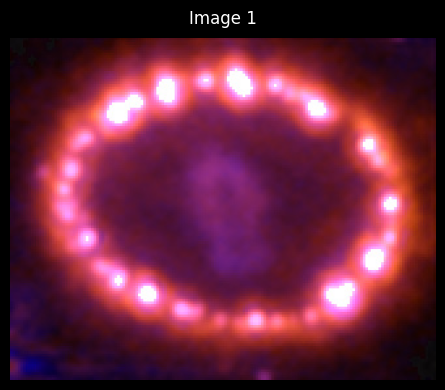

  📷 Image 1 - Caption: Sept. 24, 1994
Feb. 6, 1998
Mar. 23, 2001 Jan. 5, 2003
Dec. 15, 2004
Dec. 6, 2006 A shock wave of material from the central, exploded star of SN 1987A is slamming into an 
existing ring of material around the doomed star. As it does, various spots in the ring are heated 
and begin to glow. The nature of the strangely shaped pink feature in the center of the ring is 
not well understood.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 2] ID: 2
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the context provide numerical uncertainty, 

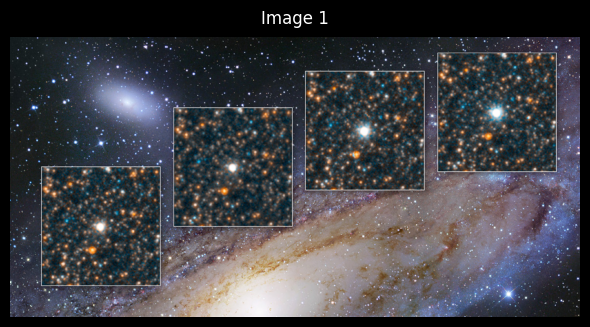

  📷 Image 1 - Caption: Background photo: R. Gendler Above: Astronomers use cyclical changes in the 
brightness of Cepheid stars to determine astronomical 
distances. The arrow points to a Cepheid star in the 
Andromeda galaxy observed by Hubble (inset boxes).


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 3] ID: 3
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the context provide enough procedural detail to independently reproduce the Hubble Deep Field supernova identification process?

📄 TEXT CONTEXT:
[1] Turning its sights to the tattered remains of a

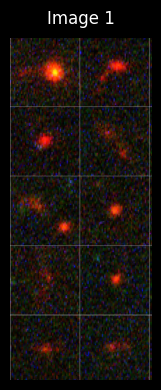

  📷 Image 1 - Caption: Left: Hubble’s Ultra Deep Field is one of the most distant looks into 
space ever. The cumulative exposure time needed to capture the 
image was about a million seconds (11 days). Right: A sample of the faintest and farthest galaxies in the Hubble 
Ultra Deep Field shows that they were irregularly shaped and 
frequently interacting in the distant past.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 4] ID: 4
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Do the provided images alone visually demonstrate cyclical brightness changes requi

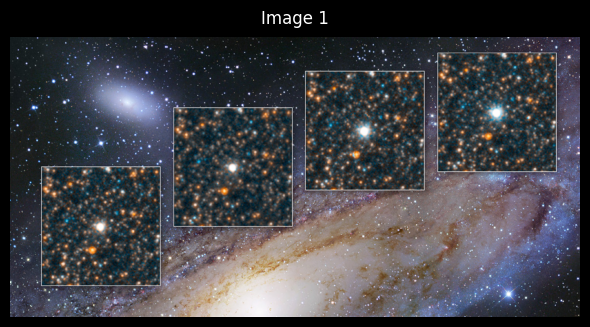

  📷 Image 1 - Caption: Background photo: R. Gendler Above: Astronomers use cyclical changes in the 
brightness of Cepheid stars to determine astronomical 
distances. The arrow points to a Cepheid star in the 
Andromeda galaxy observed by Hubble (inset boxes).


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 5] ID: 5
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Is the identification of the Deep Field supernova visually supported by the image itself, or only by temporal comparison described in the text?

📄 TEXT CONTEXT:
[1] Supernova 1987A as seen by 
Hubble i

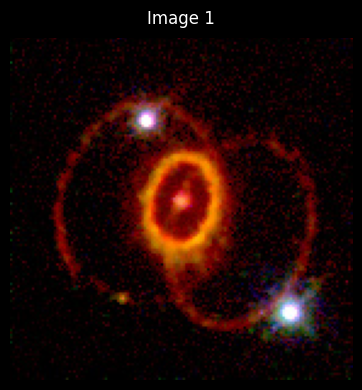

  📷 Image 1 - Caption: Supernova 1987A as seen by 
Hubble in 1994.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 6] ID: 6
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the Pillars of Creation description rely solely on visible structures in the image, or does it include interpretive claims beyond what is directly observable?

📄 TEXT CONTEXT:
[1] One of 
One of Hubble
Hubble’s most iconic images is of this portion of the Eagle Nebula 
’s most iconic images is of this portion of the Eagle Nebula 
(M16). Dubbed the “Pillars of Creation,” it shows star bi

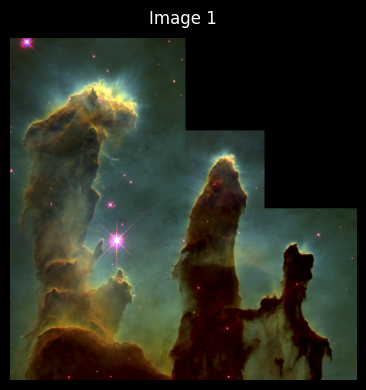

  📷 Image 1 - Caption: In 1609, visionary Italian scientist Galileo Galilei turned the newly invented optical device of his day—the telescope—to view 
the heavens. His observations conclusively showed that there were celestial bodies (the moons of Jupiter) that did not revolve 
around the Earth, launching a revolution that forever changed our view of an Earth-centered universe. Almost four centuries later, the launch of NASA’s Hubble Space Telescope aboard the 
Space Shuttle Discovery in 1990 started another revolution in astronomy. Developed as a 
partnership between the United States space program and the European Space Agency, 
Hubble orbits 340 miles above Earth’s surface. Its gaze outward lies beyond the distorting


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------

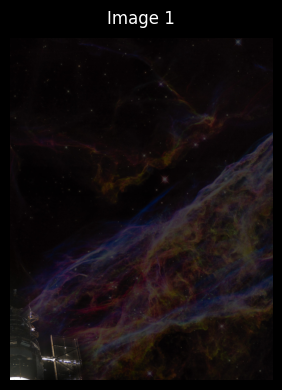

  📷 Image 1 - Caption: Uncovering Icy Objects in the Kuiper Belt


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 8] ID: 8
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the context mention any observations that would contradict or weaken the claim of ongoing star formation in the Pillars of Creation?

📄 TEXT CONTEXT:
[1] One of 
One of Hubble
Hubble’s most iconic images is of this portion of the Eagle Nebula 
’s most iconic images is of this portion of the Eagle Nebula 
(M16). Dubbed the “Pillars of Creation,” it shows star birth. Imbedded in 
(M16). Dub

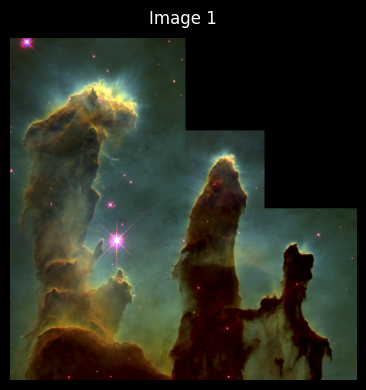

  📷 Image 1 - Caption: In 1609, visionary Italian scientist Galileo Galilei turned the newly invented optical device of his day—the telescope—to view 
the heavens. His observations conclusively showed that there were celestial bodies (the moons of Jupiter) that did not revolve 
around the Earth, launching a revolution that forever changed our view of an Earth-centered universe. Almost four centuries later, the launch of NASA’s Hubble Space Telescope aboard the 
Space Shuttle Discovery in 1990 started another revolution in astronomy. Developed as a 
partnership between the United States space program and the European Space Agency, 
Hubble orbits 340 miles above Earth’s surface. Its gaze outward lies beyond the distorting


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------

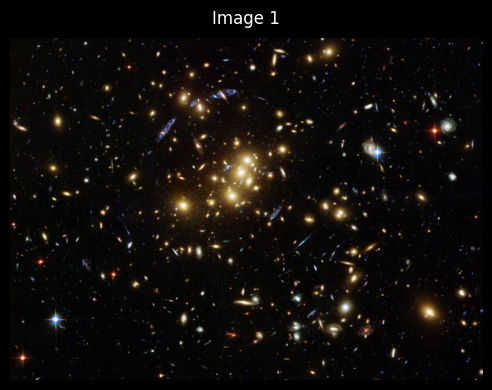

  📷 Image 1 - Caption: Top left: This sketch shows paths of light from a distant galaxy that is being gravitationally lensed. Top right: Gravitational lensing has created 
three distorted images of the same background galaxy and five of a background quasar in this image of galaxy cluster SDSS J1004+4112. Bottom: These two pictures show a massive galaxy cluster, Cl 0024+17. The visible-light image (left) shows blue arcs among the yellowish  
galaxies. These arcs are magnified, warped images of galaxies located behind the cluster whose light has been distorted and bent. The blue  
overlay (right) shows the dark matter density needed to account for the gravitational distortions.


----------------------------------------------------------------------------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------------------------------------------------------------------

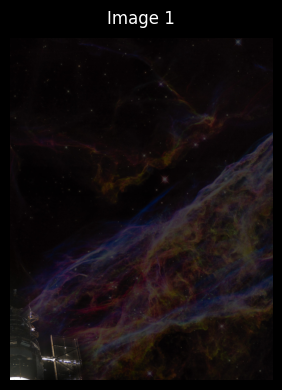

  📷 Image 1 - Caption: Shining a Light on Dark Matter


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 11] ID: 11
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the black hole interpretation in galaxy M84 explicitly rule out alternative explanations such as dense star clusters using observational constraints?

📄 TEXT CONTEXT:
[1] Shown here are two Hubble views of the galaxy M84. Left: This camera view shows the bright core at the center of the galaxy surrounded by 
a (vertical) dark band of gas and dust. Right: This plot was generated by passing light ne

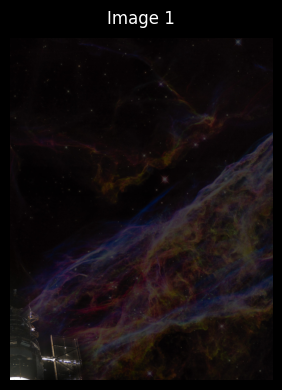

  📷 Image 1 - Caption: Tracing the Growth of Galaxies


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 12] ID: 12
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the Jupiter impact description establish causality purely from observed image sequences, or does it rely on prior knowledge of impact events?

📄 TEXT CONTEXT:
[1] Studying the Outer Planets and Moons
Hubble has witnessed impacts on Jupiter that were produced 
by minor bodies in the solar system. The latest collision 
observed by Hubble occurred in 2009 when a suspected 
asteroid plunged into Jupit

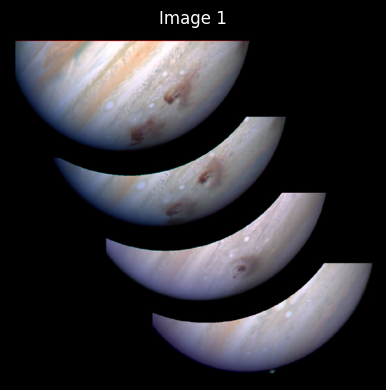

  📷 Image 1 - Caption: Studying the Outer Planets and Moons This image series, starting in the lower right corner, shows the 
darkening of Jupiter’s clouds as a result of the impact of Comet 
Shoemaker-Levy 9. Hubble captured a colossal plume rising above the limb of Jupiter 
from the impact of the first large fragment of Comet Shoemaker-Levy 9. 
(Times along the left side are in hour:minute format.)


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 13] ID: 13
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the Europa plume interpretation present a direct c

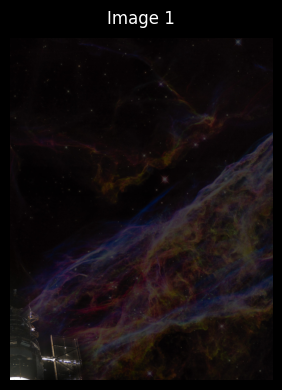

  📷 Image 1 - Caption: Viewing Galactic Details and Mergers


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 14] ID: 14
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the Pluto composite image explanation include sufficient detector or exposure metadata to independently validate the imaging strategy?

📄 TEXT CONTEXT:
[1] Hubble’s view of Pluto 
provided NASA’s New 
Horizons mission with 
the best available 
information for planning 
its rendezvous with the 
dwarf planet.
(Source: highlights_of_hubbles_exploration_of_the_universe.pdf, page 10)

[2] This gr

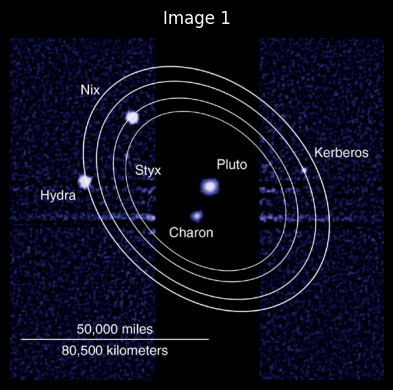

  📷 Image 1 - Caption: Uncovering Icy Objects in the Kuiper Belt This graphic combines images taken by Hubble in July 2012. 
A long exposure (blue areas) captures the tiny moons, while a 
shorter exposure (vertical black band) shows Pluto and Charon 
more clearly. (Objects not to scale.)


----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 15] ID: 15
----------------------------------------------------------------------------------------------------------------------------------------------------------------

📌 Expected Images: None
📝 Query: Does the Voyager mission description provide enough quantitative trajectory or timing data to independently reconstruct the spacecraft flyby sequence?

📄 TEXT CONTEXT:
[1

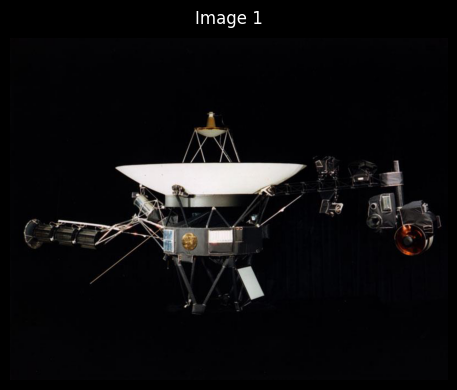

  📷 Image 1 - Caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 to send it on to Uranus 
and maybe even Neptune – assuming it would survive that long! Just 13 days after its launch, Voyager 1 scored the first of its many firsts:  at a distance of 7.25 million 
miles, it turned its camera back toward Earth and snapped the first ever photograph of the Earth-Moon 
system in a single frame, giving a sneak preview of the discoveries that lay ahead. First photograph of the Earth-Moon system in a single frame (left), taken by Voyager 1 on September 18, 
1977.  Voyager spacecraft as it would appear in space (right).  Images courtesy of NASA.


----------------------------------------------------------------------------------------------------------------------------------------------------------------




In [33]:
display_formatted_results(retrieval_output, formatter)